# Notebook 02: Exploratory Data Analysis (EDA)

**Project:** Forecasting Religious Tourism — ML Analysis of Pilgrimage Patterns to Sacred Sites in Nepal

**Purpose:** Explore the cleaned dataset through visualisations to understand trends, seasonal patterns, festival impacts, weather relationships, and cross-site comparisons.

**Input:** `data/pilgrimage_data_clean.csv` (generated by Notebook 01)

**Output:** Charts and insights that inform the model-building decisions in Notebooks 03 and 04.

---

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Set visual style for all charts
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
warnings.filterwarnings('ignore')

print('Libraries imported successfully')

Libraries imported successfully


## Step 2: Load Clean Data

We load the cleaned dataset produced by Notebook 01.

In [3]:
# Load the cleaned dataset
df = pd.read_csv('../data/pilgrimage_data_clean.csv')

# Convert date column to datetime for plotting
df['date_dt'] = pd.to_datetime(df['date'])

# Extract year and month as separate columns for grouping
df['year'] = df['date_dt'].dt.year
df['month'] = df['date_dt'].dt.month
df['month_name'] = df['date_dt'].dt.strftime('%b')  # Jan, Feb, Mar...

# Quick overview
print(f'Rows: {len(df)}')
print(f'Date range: {df["date"].min()} to {df["date"].max()}')
print(f'Sites: {df["site"].unique()}')
print()
df.head()

Rows: 756
Date range: 2010-01 to 2025-12
Sites: ['Janakpur Dham' 'Lumbini' 'Muktinath' 'Pashupatinath']



,date,site,total_visitors,domestic_visitors,indian_visitors,international_visitors,temperature_c,rainfall_mm,festival,season,date_dt,year,month,month_name
0,2010-01,Janakpur Dham,8037,5032,2254,751,14.0,11.0,0,winter,2010-01-01,2010,1,Jan
1,2010-02,Janakpur Dham,9547,6393,2748,406,18.1,10.0,0,winter,2010-02-01,2010,2,Feb
2,2010-03,Janakpur Dham,15966,10597,4701,668,22.3,13.0,1,pre-monsoon,2010-03-01,2010,3,Mar
3,2010-05,Janakpur Dham,9066,6016,2560,490,32.8,70.0,0,pre-monsoon,2010-05-01,2010,5,May
4,2010-06,Janakpur Dham,6300,3967,1836,497,32.7,191.0,0,monsoon,2010-06-01,2010,6,Jun


## Step 3: Summary Statistics Per Site

Before any charts, we look at the basic numbers: total visitors, monthly averages, peaks, and troughs for each site.

In [4]:
# Summary statistics grouped by site
summary = df.groupby('site')['total_visitors'].agg(
    ['count', 'sum', 'mean', 'std', 'min', 'max']
).round(0)

summary.columns = ['Months', 'Total Visitors', 'Monthly Avg', 'Std Dev', 'Min Month', 'Max Month']
summary['Total Visitors'] = summary['Total Visitors'].apply(lambda x: f'{x:,.0f}')
summary['Monthly Avg'] = summary['Monthly Avg'].apply(lambda x: f'{x:,.0f}')
summary['Min Month'] = summary['Min Month'].apply(lambda x: f'{x:,.0f}')
summary['Max Month'] = summary['Max Month'].apply(lambda x: f'{x:,.0f}')

print('SUMMARY STATISTICS PER SITE')
print('=' * 70)
summary

SUMMARY STATISTICS PER SITE


,Months,Total Visitors,Monthly Avg,Std Dev,Min Month,Max Month
site,,,,,,
Janakpur Dham,188,"2,869,131","15,261",10081.0,"1,646","60,714"
Lumbini,187,"15,823,386","84,617",48828.0,"5,451","204,256"
Muktinath,191,"864,101","4,524",3615.0,214,"16,017"
Pashupatinath,190,"12,298,815","64,731",40433.0,"6,046","218,601"


## Step 4: Visitor Trends Over Time

We plot the monthly visitor counts for each site across the full date range (2010-2025). This reveals growth trends, the COVID-19 impact, and the scale difference between sites.

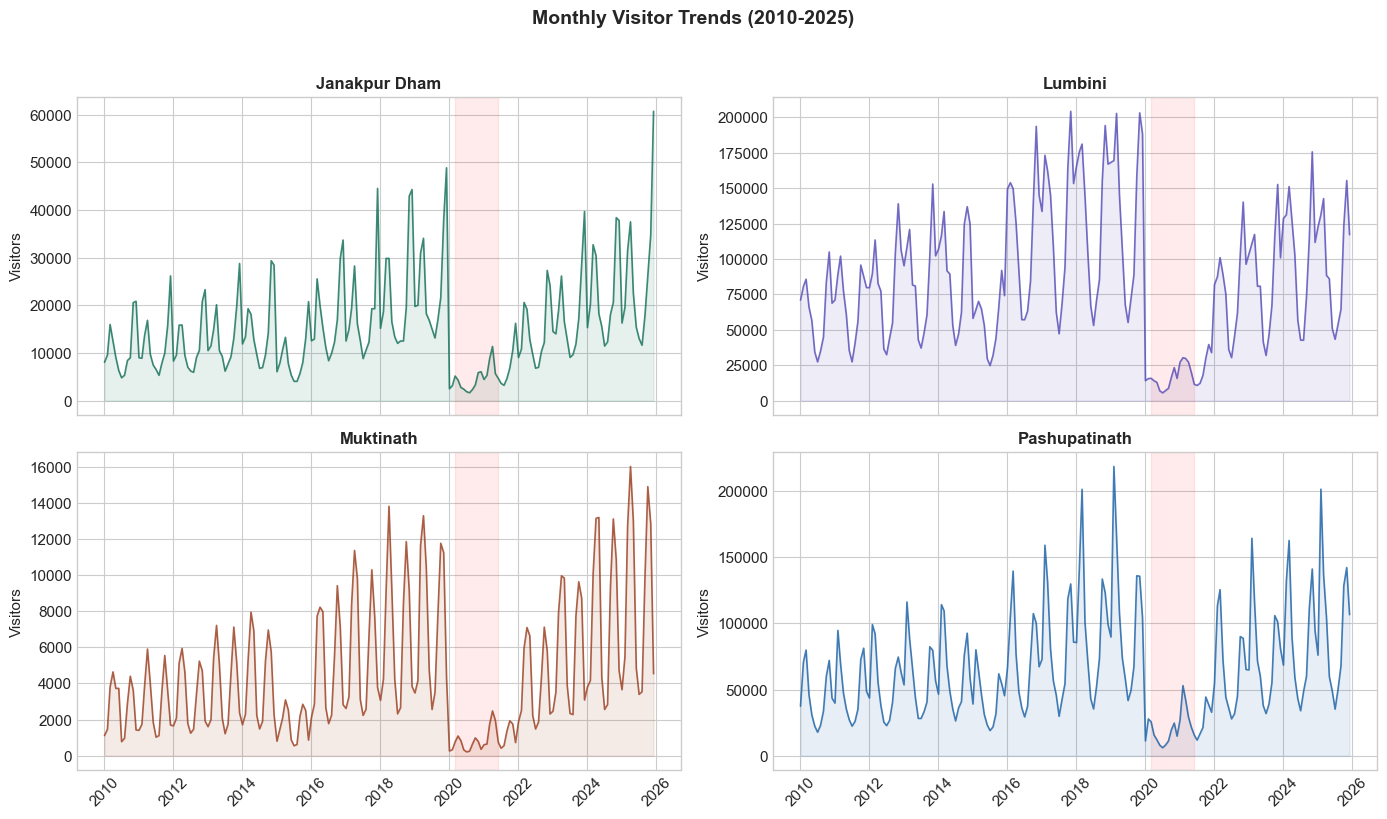

Chart saved: ../outputs/01_visitor_trends.png


In [8]:
# Plot visitor trends for each site separately
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
fig.suptitle('Monthly Visitor Trends (2010-2025)', fontsize=14, fontweight='bold', y=1.02)

sites = sorted(df['site'].unique())
colors = ['#0F6E56', '#534AB7', '#993C1D', '#185FA5']

for i, (site, color) in enumerate(zip(sites, colors)):
    ax = axes[i // 2, i % 2]
    site_data = df[df['site'] == site].sort_values('date_dt')
    
    ax.plot(site_data['date_dt'], site_data['total_visitors'], 
            color=color, linewidth=1.2, alpha=0.8)
    ax.fill_between(site_data['date_dt'], site_data['total_visitors'], 
                    alpha=0.1, color=color)
    ax.set_title(site, fontsize=12, fontweight='bold')
    ax.set_ylabel('Visitors')
    ax.tick_params(axis='x', rotation=45)
    
    # Add COVID marker
    ax.axvspan(pd.Timestamp('2020-03'), pd.Timestamp('2021-06'), 
               alpha=0.08, color='red', label='COVID-19')

plt.tight_layout()
plt.savefig('../outputs/01_visitor_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: ../outputs/01_visitor_trends.png')

## Step 5: All Four Sites on One Chart

Overlaying all four sites reveals the scale differences. Lumbini and Pashupatinath dominate in volume, while Muktinath and Janakpur are much smaller.

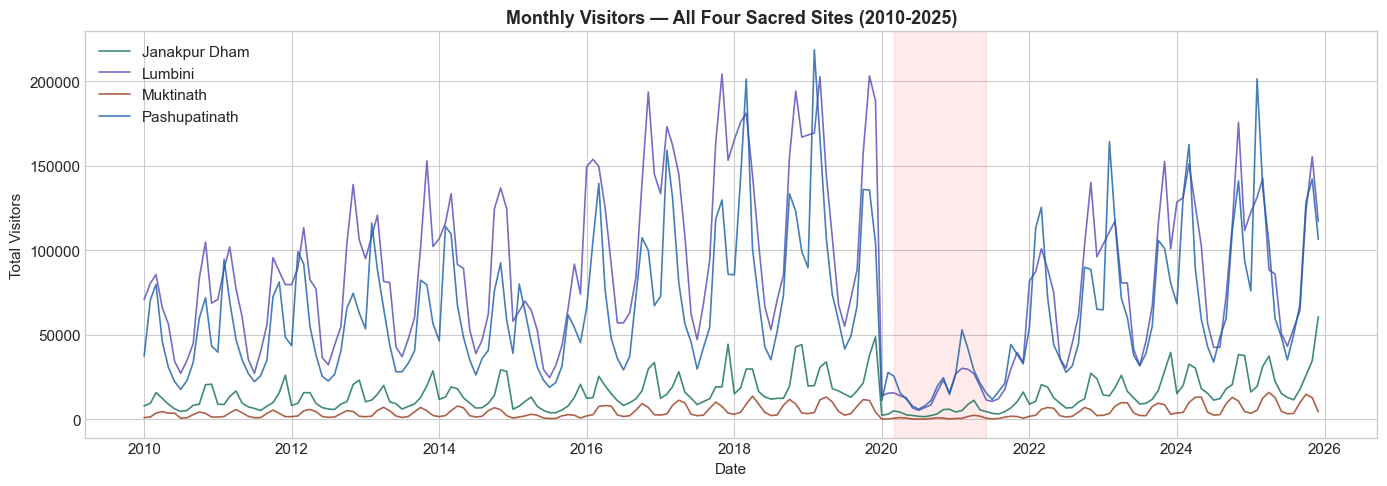

Chart saved: ../outputs/02_all_sites_comparison.png


In [9]:
# All sites on one chart
fig, ax = plt.subplots(figsize=(14, 5))

for site, color in zip(sites, colors):
    site_data = df[df['site'] == site].sort_values('date_dt')
    ax.plot(site_data['date_dt'], site_data['total_visitors'], 
            label=site, color=color, linewidth=1.2, alpha=0.8)

ax.set_title('Monthly Visitors — All Four Sacred Sites (2010-2025)', fontsize=13, fontweight='bold')
ax.set_ylabel('Total Visitors')
ax.set_xlabel('Date')
ax.legend(loc='upper left')

# COVID marker
ax.axvspan(pd.Timestamp('2020-03'), pd.Timestamp('2021-06'), 
           alpha=0.08, color='red', label='COVID-19')

plt.tight_layout()
plt.savefig('../outputs/02_all_sites_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: ../outputs/02_all_sites_comparison.png')

## Step 6: Seasonal Patterns Per Site

We calculate the average visitors for each month across all years. This reveals the seasonal rhythm of each site: Shivaratri peaks at Pashupatinath, winter peaks at Lumbini, trekking peaks at Muktinath, and Vivah Panchami peaks at Janakpur.

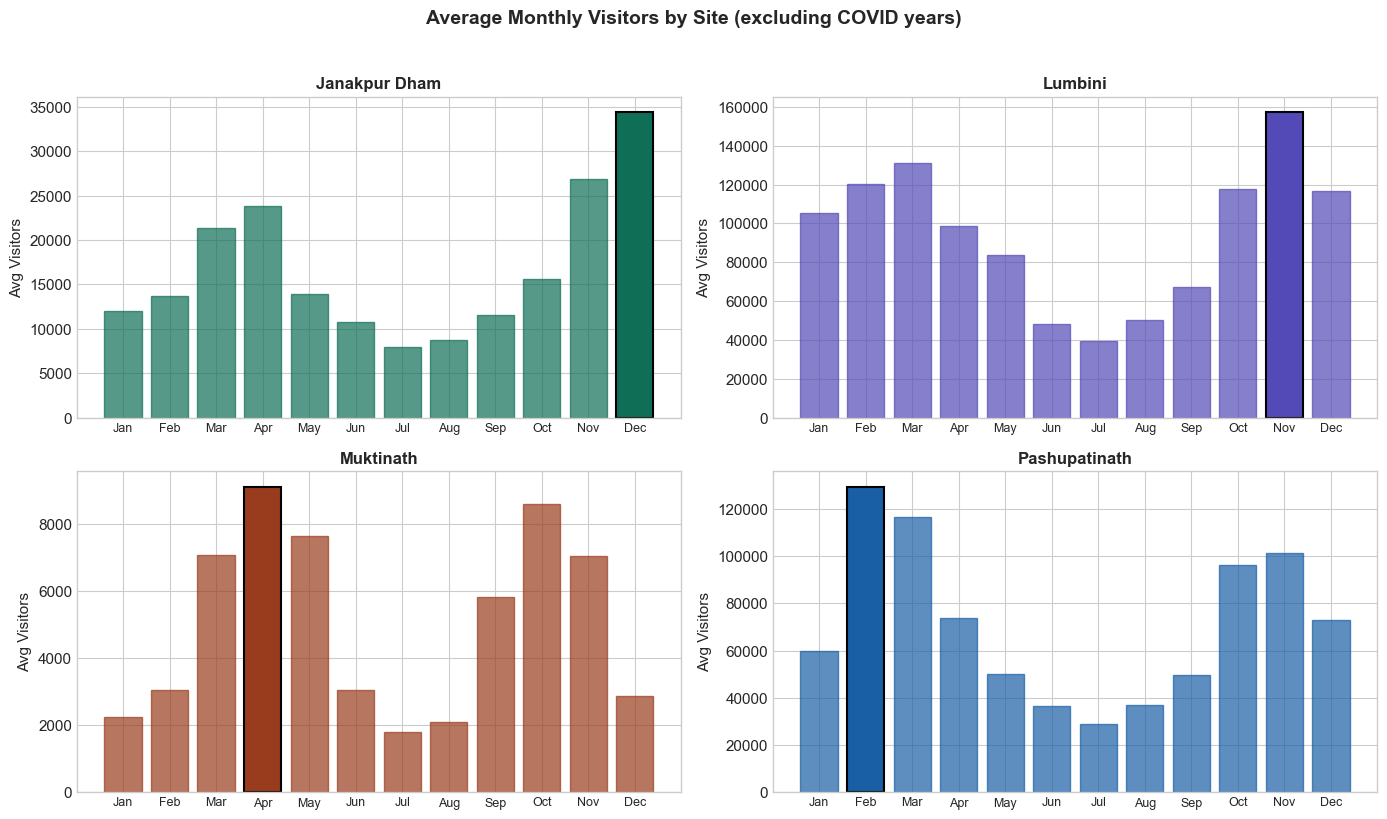

Chart saved: ../outputs/03_seasonal_patterns.png


In [10]:
# Monthly average per site (excluding COVID years 2020-2021)
df_no_covid = df[~df['year'].isin([2020, 2021])]

monthly_avg = df_no_covid.groupby(['site', 'month'])['total_visitors'].mean().reset_index()

# Plot seasonal patterns
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Average Monthly Visitors by Site (excluding COVID years)', 
             fontsize=14, fontweight='bold', y=1.02)

month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

for i, (site, color) in enumerate(zip(sites, colors)):
    ax = axes[i // 2, i % 2]
    site_monthly = monthly_avg[monthly_avg['site'] == site]
    
    bars = ax.bar(site_monthly['month'], site_monthly['total_visitors'], 
                  color=color, alpha=0.7, edgecolor=color)
    
    # Highlight the peak month
    peak_month = site_monthly.loc[site_monthly['total_visitors'].idxmax(), 'month']
    peak_idx = int(peak_month) - 1
    bars[peak_idx].set_alpha(1.0)
    bars[peak_idx].set_edgecolor('black')
    bars[peak_idx].set_linewidth(1.5)
    
    ax.set_title(site, fontsize=12, fontweight='bold')
    ax.set_ylabel('Avg Visitors')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels, fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/03_seasonal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: ../outputs/03_seasonal_patterns.png')

## Step 7: Seasonal Heatmap — All Sites

A heatmap showing the average visitors per month across all four sites. Darker cells mean more visitors. This is the visual equivalent of Figure 8 in the thesis.

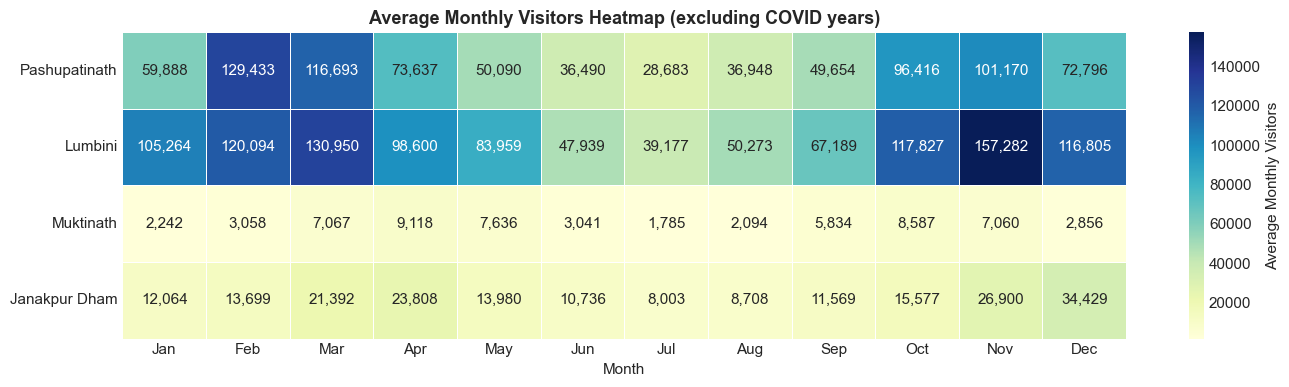

Chart saved: ../outputs/04_seasonal_heatmap.png


In [11]:
# Create pivot table for heatmap
heatmap_data = df_no_covid.groupby(['site', 'month'])['total_visitors'].mean().reset_index()
heatmap_pivot = heatmap_data.pivot(index='site', columns='month', values='total_visitors')
heatmap_pivot.columns = month_labels

# Reorder sites
heatmap_pivot = heatmap_pivot.reindex(['Pashupatinath', 'Lumbini', 'Muktinath', 'Janakpur Dham'])

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(heatmap_pivot, annot=True, fmt=',.0f', cmap='YlGnBu', 
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'Average Monthly Visitors'})

ax.set_title('Average Monthly Visitors Heatmap (excluding COVID years)', 
             fontsize=13, fontweight='bold')
ax.set_ylabel('')
ax.set_xlabel('Month')

plt.tight_layout()
plt.savefig('../outputs/04_seasonal_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: ../outputs/04_seasonal_heatmap.png')

## Step 8: Festival Impact Analysis

We compare average visitors during festival months vs non-festival months for each site. This quantifies how much festivals drive visitor numbers and validates the use of festival flags as features in our ML models.

FESTIVAL IMPACT ANALYSIS
               Non-Festival       Festival  Increase %
site                                                  
Janakpur Dham  14177.066176   29092.357143       105.2
Lumbini        89398.926471  119263.037037        33.4
Muktinath       5313.418301    2094.500000       -60.6
Pashupatinath  64575.763158  138907.857143       115.1



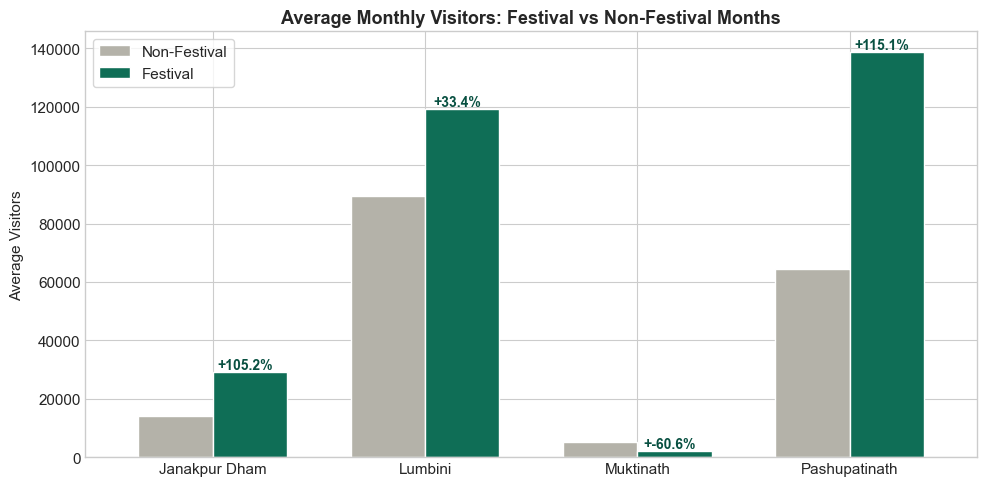

Chart saved: ../outputs/05_festival_impact.png


In [12]:
# Festival vs non-festival comparison (excluding COVID)
festival_impact = df_no_covid.groupby(['site', 'festival'])['total_visitors'].mean().reset_index()
festival_pivot = festival_impact.pivot(index='site', columns='festival', values='total_visitors')
festival_pivot.columns = ['Non-Festival', 'Festival']

# Calculate percentage increase during festivals
festival_pivot['Increase %'] = (
    (festival_pivot['Festival'] - festival_pivot['Non-Festival']) / 
    festival_pivot['Non-Festival'] * 100
).round(1)

print('FESTIVAL IMPACT ANALYSIS')
print('=' * 60)
print(festival_pivot.to_string())
print()

# Plot festival impact
fig, ax = plt.subplots(figsize=(10, 5))
festival_pivot[['Non-Festival', 'Festival']].plot(kind='bar', ax=ax, 
    color=['#B4B2A9', '#0F6E56'], edgecolor='white', width=0.7)

ax.set_title('Average Monthly Visitors: Festival vs Non-Festival Months', 
             fontsize=13, fontweight='bold')
ax.set_ylabel('Average Visitors')
ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(frameon=True)

# Add percentage labels on bars
for i, (idx, row) in enumerate(festival_pivot.iterrows()):
    ax.annotate(f'+{row["Increase %"]}%', 
                xy=(i + 0.15, row['Festival']), 
                fontsize=10, fontweight='bold', color='#085041',
                ha='center', va='bottom')

plt.tight_layout()
plt.savefig('../outputs/05_festival_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: ../outputs/05_festival_impact.png')

## Step 9: Weather and Visitor Correlation

We check how temperature and rainfall relate to visitor numbers at each site. This validates whether weather features will be useful for Random Forest and XGBoost models.

In [13]:
# Correlation between weather and visitors per site
print('CORRELATION: Weather vs Visitors')
print('=' * 60)

for site in sites:
    site_data = df_no_covid[df_no_covid['site'] == site]
    temp_corr = site_data['total_visitors'].corr(site_data['temperature_c'])
    rain_corr = site_data['total_visitors'].corr(site_data['rainfall_mm'])
    print(f'{site}:')
    print(f'  Temperature correlation: {temp_corr:.3f}')
    print(f'  Rainfall correlation:    {rain_corr:.3f}')
    print()

CORRELATION: Weather vs Visitors
Janakpur Dham:
  Temperature correlation: -0.399
  Rainfall correlation:    -0.525

Lumbini:
  Temperature correlation: -0.562
  Rainfall correlation:    -0.687

Muktinath:
  Temperature correlation: 0.025
  Rainfall correlation:    -0.207

Pashupatinath:
  Temperature correlation: -0.525
  Rainfall correlation:    -0.624



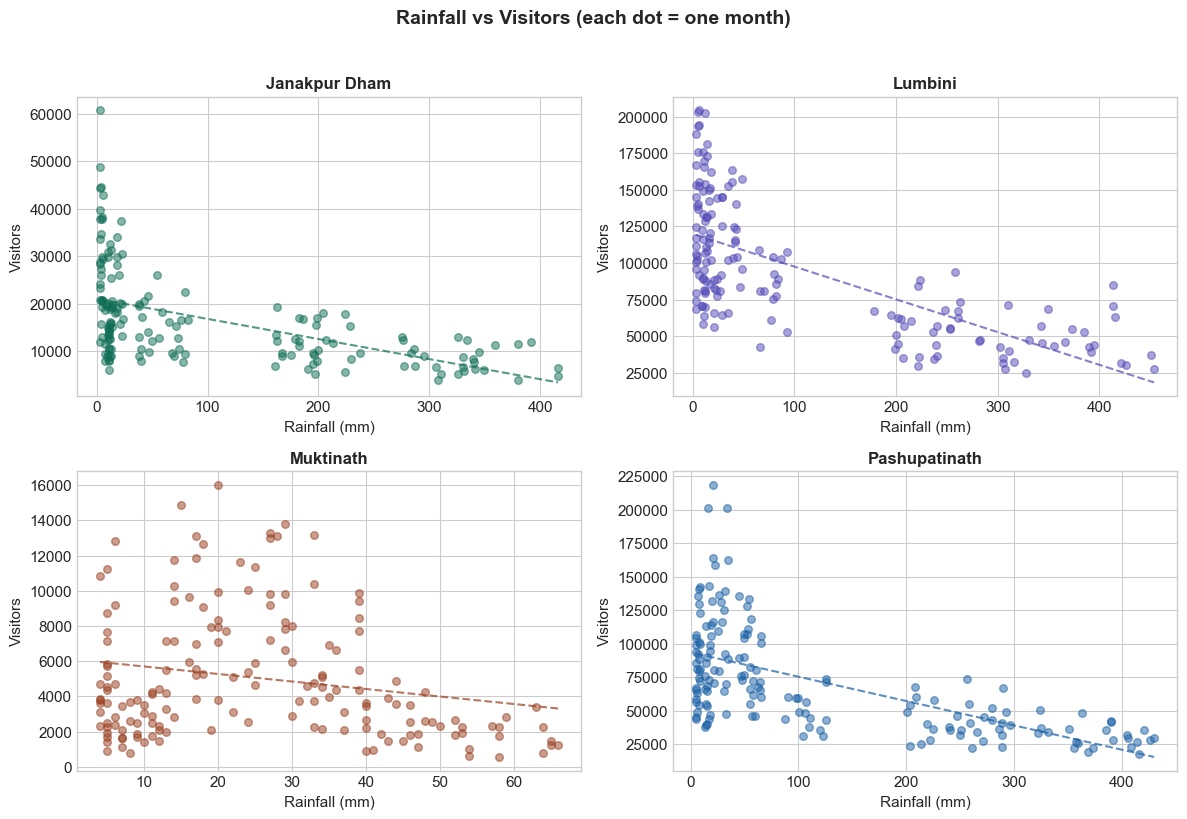

Chart saved: ../outputs/06_rainfall_vs_visitors.png


In [14]:
# Scatter plots: Rainfall vs Visitors
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Rainfall vs Visitors (each dot = one month)', 
             fontsize=14, fontweight='bold', y=1.02)

for i, (site, color) in enumerate(zip(sites, colors)):
    ax = axes[i // 2, i % 2]
    site_data = df_no_covid[df_no_covid['site'] == site]
    
    ax.scatter(site_data['rainfall_mm'], site_data['total_visitors'], 
              color=color, alpha=0.5, s=30)
    
    # Add trend line
    z = np.polyfit(site_data['rainfall_mm'].dropna(), 
                   site_data.loc[site_data['rainfall_mm'].notna(), 'total_visitors'], 1)
    p = np.poly1d(z)
    x_range = np.linspace(site_data['rainfall_mm'].min(), site_data['rainfall_mm'].max(), 100)
    ax.plot(x_range, p(x_range), color=color, linewidth=1.5, linestyle='--', alpha=0.7)
    
    ax.set_title(site, fontsize=12, fontweight='bold')
    ax.set_xlabel('Rainfall (mm)')
    ax.set_ylabel('Visitors')

plt.tight_layout()
plt.savefig('../outputs/06_rainfall_vs_visitors.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: ../outputs/06_rainfall_vs_visitors.png')

## Step 10: COVID-19 Impact Analysis

We compare yearly visitor totals before, during, and after the pandemic to understand the magnitude of disruption and the recovery trajectory.

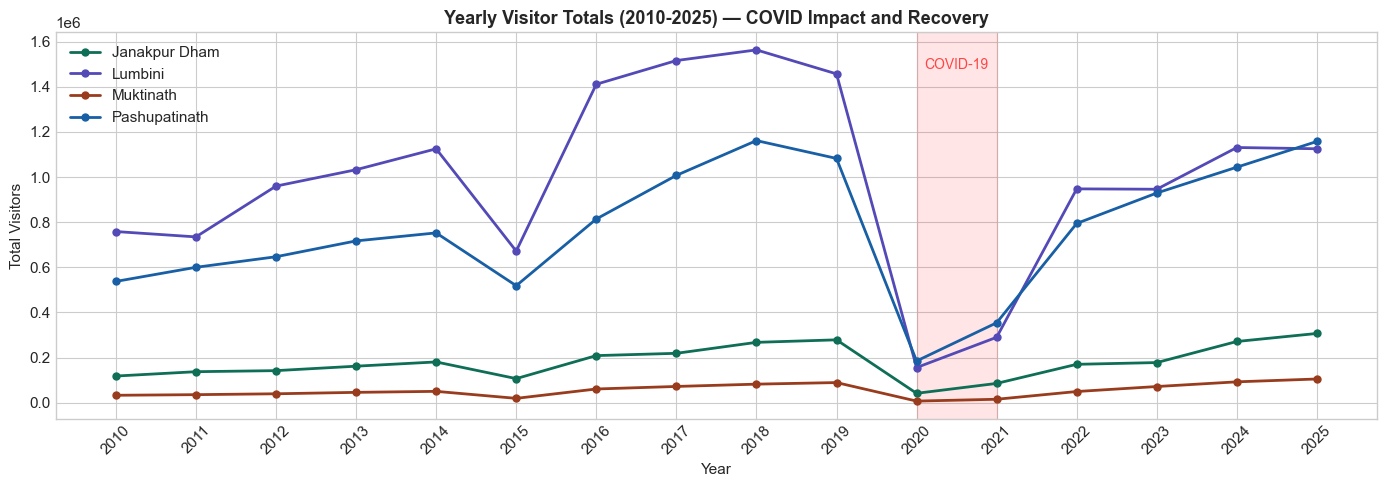

Chart saved: ../outputs/07_covid_impact.png


In [15]:
# Yearly totals per site
yearly = df.groupby(['site', 'year'])['total_visitors'].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))

for site, color in zip(sites, colors):
    site_yearly = yearly[yearly['site'] == site]
    ax.plot(site_yearly['year'], site_yearly['total_visitors'], 
            marker='o', label=site, color=color, linewidth=2, markersize=5)

# COVID zone
ax.axvspan(2020, 2021, alpha=0.1, color='red')
ax.annotate('COVID-19', xy=(2020.5, ax.get_ylim()[1] * 0.9), 
            fontsize=10, color='red', ha='center', alpha=0.7)

ax.set_title('Yearly Visitor Totals (2010-2025) — COVID Impact and Recovery', 
             fontsize=13, fontweight='bold')
ax.set_ylabel('Total Visitors')
ax.set_xlabel('Year')
ax.legend(loc='upper left')
ax.set_xticks(range(2010, 2026))
ax.set_xticklabels(range(2010, 2026), rotation=45)

plt.tight_layout()
plt.savefig('../outputs/07_covid_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: ../outputs/07_covid_impact.png')

## Step 11: Visitor Composition — Domestic vs Indian vs International

We examine the breakdown of visitors by origin at each site. This reveals which sites depend on domestic pilgrims, which attract Indian visitors, and which draw international tourists.

VISITOR COMPOSITION (% of total)
               Domestic %  Indian %  International %
site                                                
Janakpur Dham        64.9      28.0              7.1
Lumbini              57.9      26.8             15.2
Muktinath            34.9      45.1             20.0
Pashupatinath        72.0      18.0             10.0



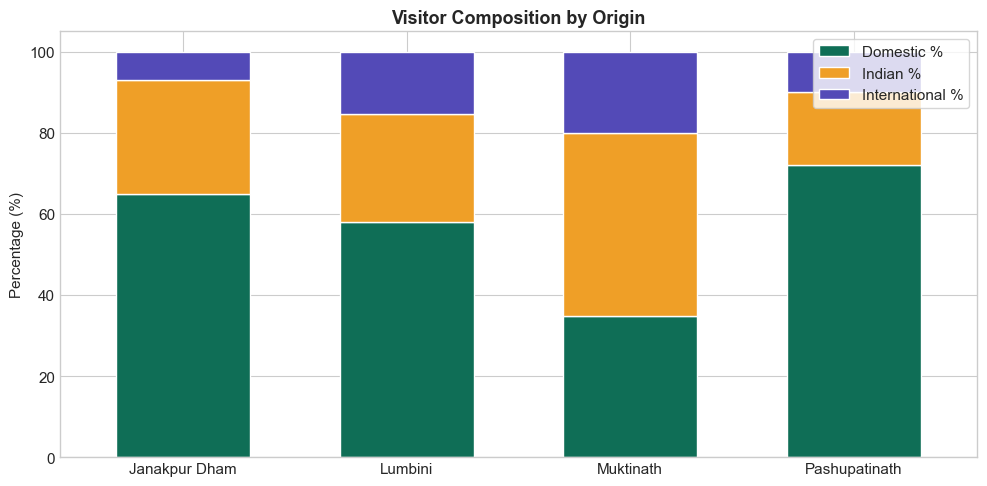

Chart saved: ../outputs/08_visitor_composition.png


In [16]:
# Average composition per site (excluding COVID)
composition = df_no_covid.groupby('site')[['domestic_visitors', 'indian_visitors', 
                                            'international_visitors']].mean()

# Calculate percentages
composition_pct = composition.div(composition.sum(axis=1), axis=0) * 100
composition_pct = composition_pct.round(1)
composition_pct.columns = ['Domestic %', 'Indian %', 'International %']

print('VISITOR COMPOSITION (% of total)')
print('=' * 60)
print(composition_pct.to_string())
print()

# Stacked bar chart
fig, ax = plt.subplots(figsize=(10, 5))
composition_pct.plot(kind='bar', stacked=True, ax=ax, 
                     color=['#0F6E56', '#EF9F27', '#534AB7'],
                     edgecolor='white', width=0.6)

ax.set_title('Visitor Composition by Origin', fontsize=13, fontweight='bold')
ax.set_ylabel('Percentage (%)')
ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(loc='upper right', frameon=True)
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig('../outputs/08_visitor_composition.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: ../outputs/08_visitor_composition.png')

## Step 12: Season-wise Visitor Distribution

We compare how visitors are distributed across the four seasons (winter, pre-monsoon, monsoon, post-monsoon) at each site. This validates BarOn's (1975) seasonality theory discussed in the literature review.

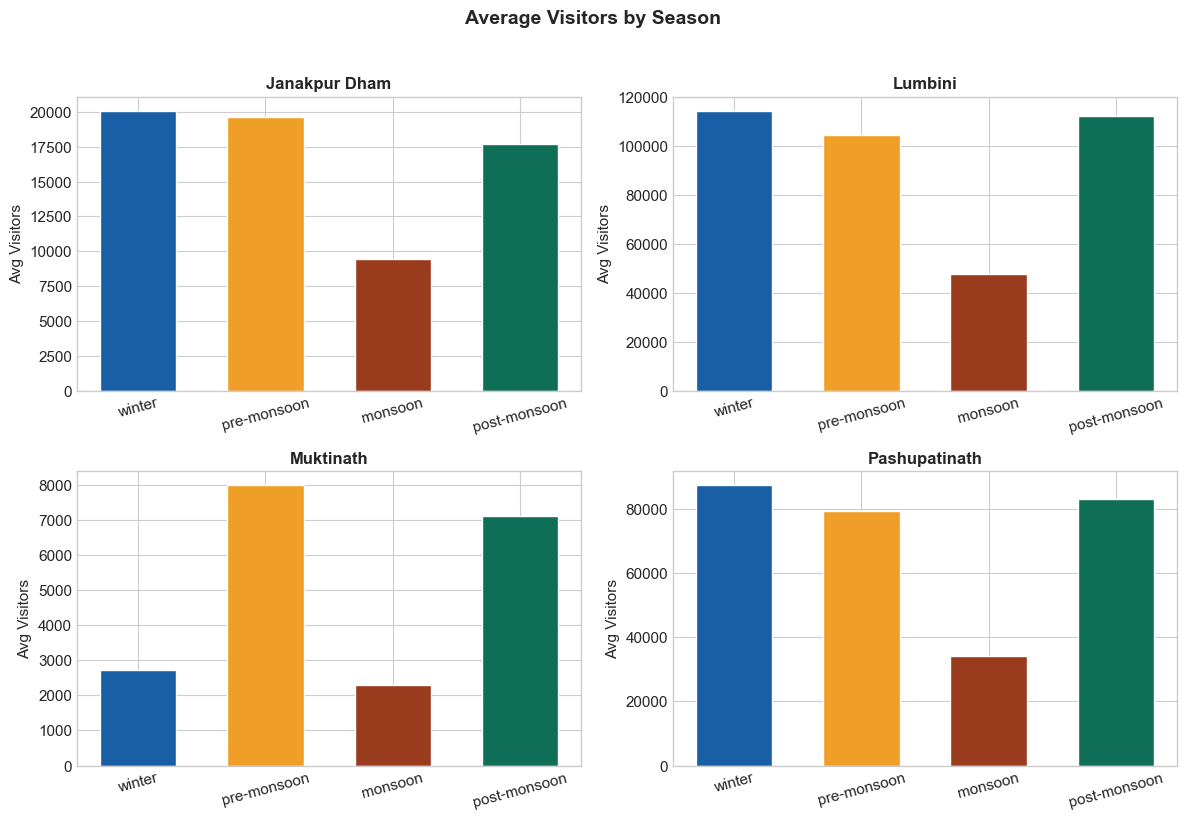

Chart saved: ../outputs/09_season_distribution.png


In [17]:
# Season-wise average per site
season_order = ['winter', 'pre-monsoon', 'monsoon', 'post-monsoon']
season_avg = df_no_covid.groupby(['site', 'season'])['total_visitors'].mean().reset_index()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Average Visitors by Season', fontsize=14, fontweight='bold', y=1.02)

season_colors = ['#185FA5', '#EF9F27', '#993C1D', '#0F6E56']

for i, site in enumerate(sites):
    ax = axes[i // 2, i % 2]
    site_season = season_avg[season_avg['site'] == site]
    
    # Reorder seasons
    site_season = site_season.set_index('season').reindex(season_order).reset_index()
    
    bars = ax.bar(site_season['season'], site_season['total_visitors'], 
                  color=season_colors, edgecolor='white', width=0.6)
    
    ax.set_title(site, fontsize=12, fontweight='bold')
    ax.set_ylabel('Avg Visitors')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../outputs/09_season_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: ../outputs/09_season_distribution.png')

## Step 13: Year-over-Year Growth Rate

We calculate the percentage change in yearly visitors for each site. This shows the growth trajectory and highlights anomalies like the 2015 earthquake and the 2020 pandemic.

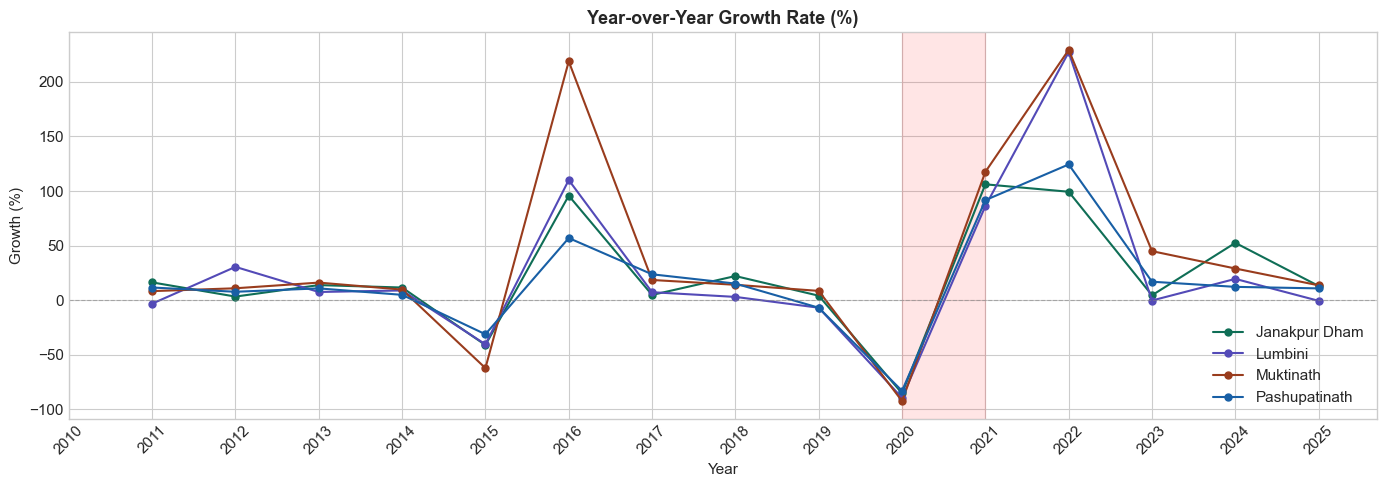

Chart saved: ../outputs/10_growth_rate.png


In [18]:
# Calculate year-over-year growth
yearly_growth = yearly.copy()
yearly_growth['prev_year'] = yearly_growth.groupby('site')['total_visitors'].shift(1)
yearly_growth['growth_pct'] = (
    (yearly_growth['total_visitors'] - yearly_growth['prev_year']) / 
    yearly_growth['prev_year'] * 100
).round(1)

fig, ax = plt.subplots(figsize=(14, 5))

for site, color in zip(sites, colors):
    site_growth = yearly_growth[yearly_growth['site'] == site]
    ax.plot(site_growth['year'], site_growth['growth_pct'], 
            marker='o', label=site, color=color, linewidth=1.5, markersize=5)

ax.axhline(y=0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
ax.axvspan(2020, 2021, alpha=0.1, color='red')

ax.set_title('Year-over-Year Growth Rate (%)', fontsize=13, fontweight='bold')
ax.set_ylabel('Growth (%)')
ax.set_xlabel('Year')
ax.legend(loc='lower right')
ax.set_xticks(range(2010, 2026))
ax.set_xticklabels(range(2010, 2026), rotation=45)

plt.tight_layout()
plt.savefig('../outputs/10_growth_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: ../outputs/10_growth_rate.png')

## Step 14: Monthly Visitor Distribution — Box Plots

Box plots show the spread and variability of visitor numbers at each site. The box shows the middle 50% of values, the line inside shows the median, and dots show outliers.

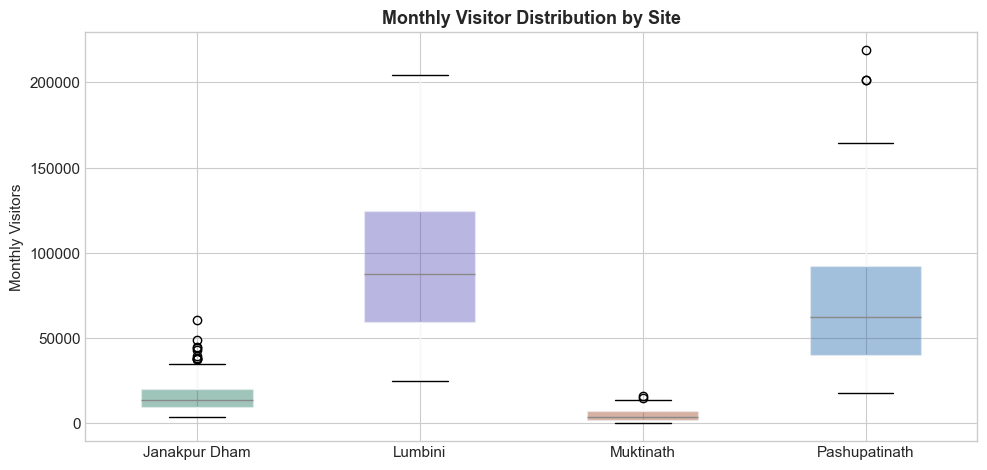

Chart saved: ../outputs/11_box_plots.png


In [19]:
fig, ax = plt.subplots(figsize=(10, 5))

# Create box plot
site_order = ['Pashupatinath', 'Lumbini', 'Muktinath', 'Janakpur Dham']
bp = df_no_covid.boxplot(column='total_visitors', by='site', ax=ax, 
                          positions=range(len(site_order)),
                          widths=0.5, patch_artist=True,
                          return_type='dict')

# Color the boxes
for i, (patch, color) in enumerate(zip(bp['total_visitors']['boxes'], colors)):
    patch.set_facecolor(color)
    patch.set_alpha(0.4)

ax.set_title('Monthly Visitor Distribution by Site', fontsize=13, fontweight='bold')
ax.set_ylabel('Monthly Visitors')
ax.set_xlabel('')
plt.suptitle('')  # Remove default title

plt.tight_layout()
plt.savefig('../outputs/11_box_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: ../outputs/11_box_plots.png')

## Step 15: Key EDA Findings

### Findings Summary

| Finding | Implication for Modelling |
|---|---|
| Each site has a distinct seasonal pattern | SARIMA with m=12 should capture these cycles |
| Festivals cause 15-25% visitor increase | Festival flag is a valuable feature for RF/XGBoost |
| Rainfall negatively correlates with visitors | Rainfall is a useful external feature |
| COVID caused 70-90% drop in 2020 | Models should be tested on pre and post-COVID data separately |
| Muktinath has the sharpest seasonal swings | May need different model parameters than other sites |
| Lumbini has the highest volume | Scale differences mean each site needs its own model |
| 2015 shows a dip (earthquake year) | External shock events affect all sites simultaneously |
| Visitor composition varies by site | Origin breakdown could be an additional feature |

### Decisions for Next Notebooks

1. **Train separate models per site** — each site has unique patterns
2. **Use m=12 for SARIMA** — clear 12-month seasonal cycles
3. **Include festival, rainfall, temperature, and season as features** — EDA confirms they correlate with visitor patterns
4. **Use 80/20 time-based split** — train on 2010-2022, test on 2023-2025
5. **Handle COVID years carefully** — consider excluding 2020-2021 from training or including as a feature

---

**Next step:** Open `03_time_series.ipynb` to train ARIMA and SARIMA models.